In [1]:
import torch
import math
import numpy as np
import pickle
import matplotlib.pyplot as plt


In [2]:
#change the working directory
import os
os.chdir('/home/shij0d/Documents/Dis_Spatial/')


[]


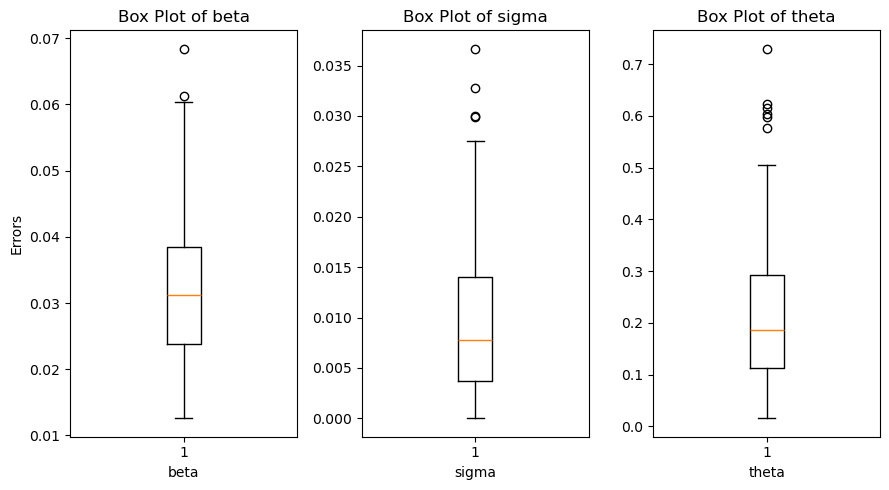

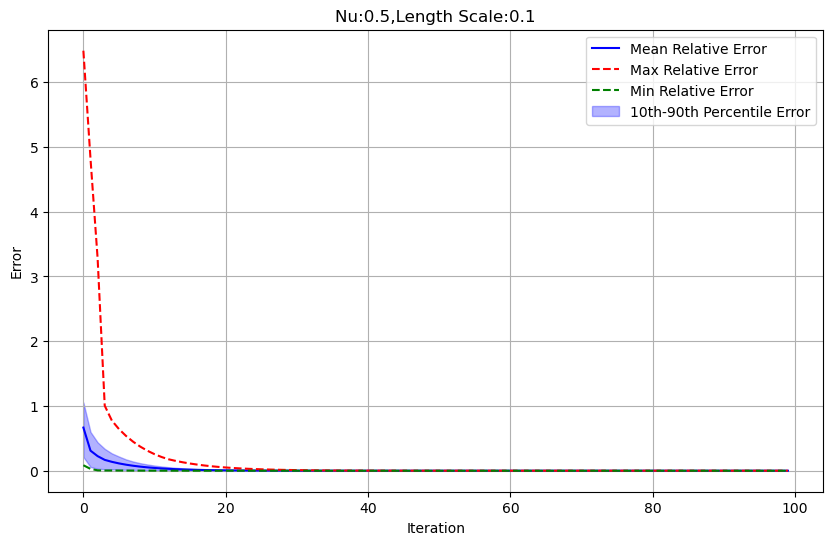

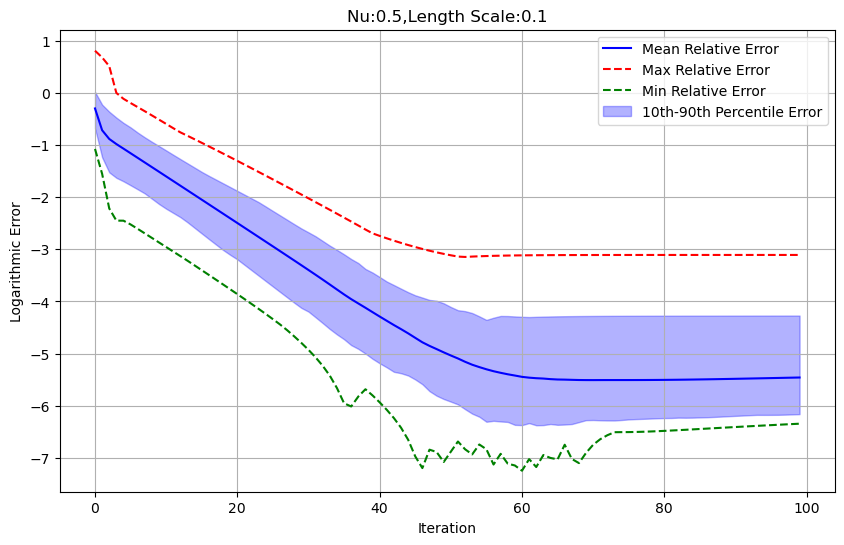

/tmp/ipykernel_3392840/4035658662.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([alphas_mle] + [alphas_de[:, j] for j in range(10)], labels=['MLE'] + [f'DE_{j+1}' for j in range(10)])
/tmp/ipykernel_3392840/4035658662.py:153: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([length_scales_mle] + [length_scales_de[:, j] for j in range(10)], labels=['MLE'] + [f'DE_{j+1}' for j in range(10)])


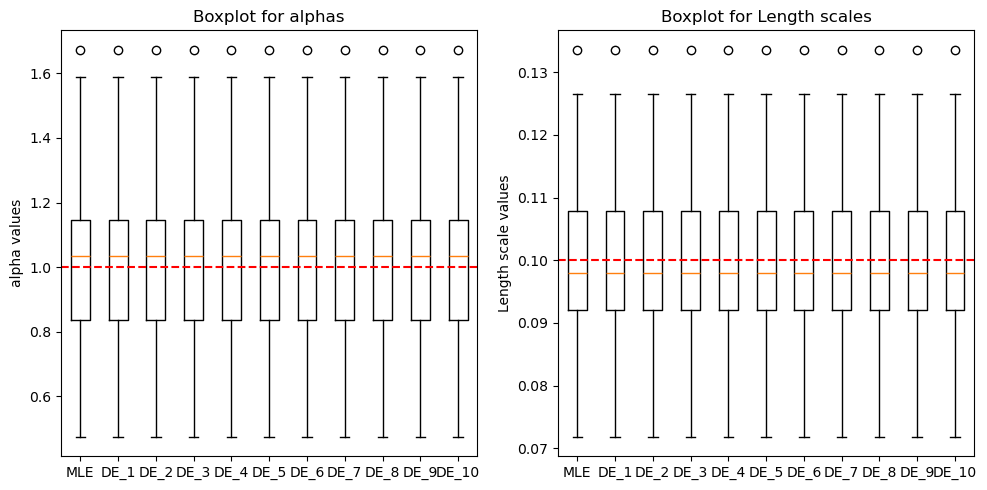

[]


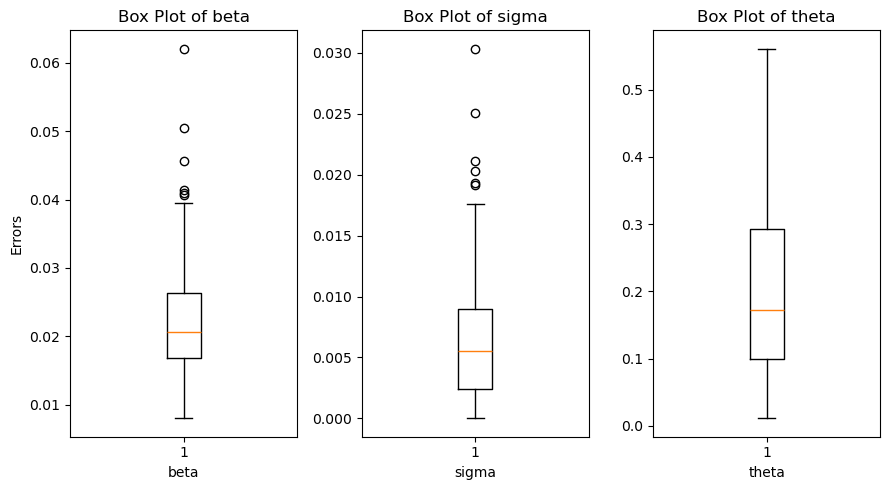

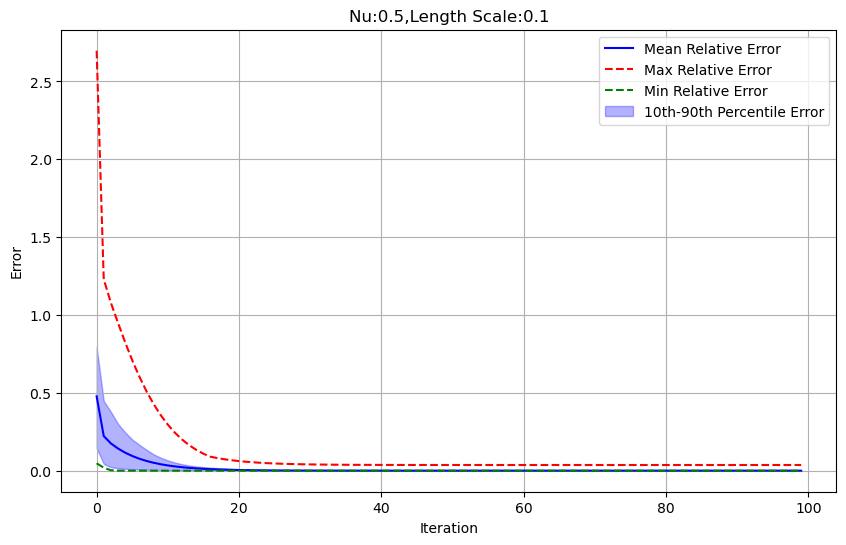

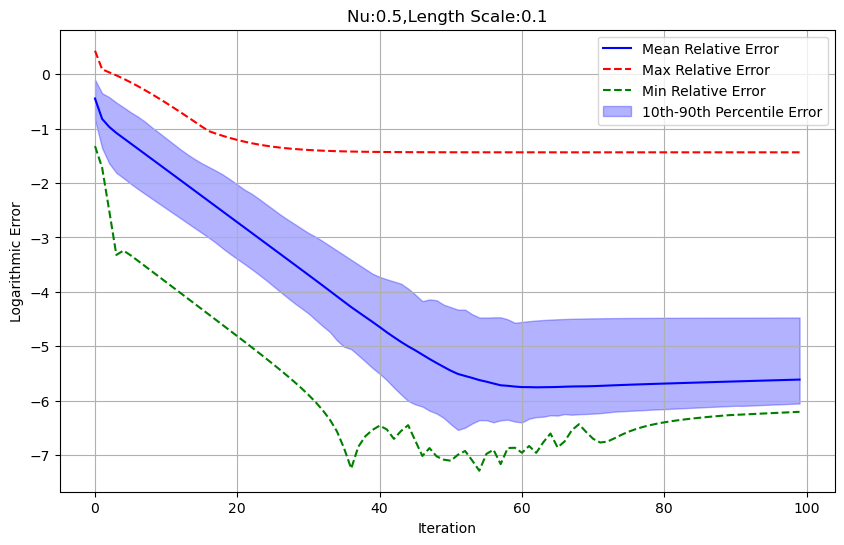

/tmp/ipykernel_3392840/4035658662.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([alphas_mle] + [alphas_de[:, j] for j in range(10)], labels=['MLE'] + [f'DE_{j+1}' for j in range(10)])
/tmp/ipykernel_3392840/4035658662.py:153: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([length_scales_mle] + [length_scales_de[:, j] for j in range(10)], labels=['MLE'] + [f'DE_{j+1}' for j in range(10)])


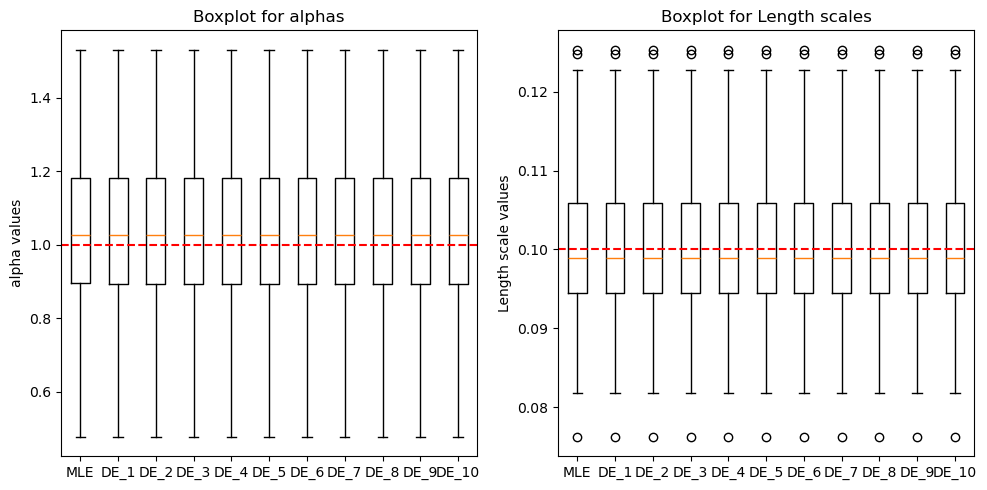

[]


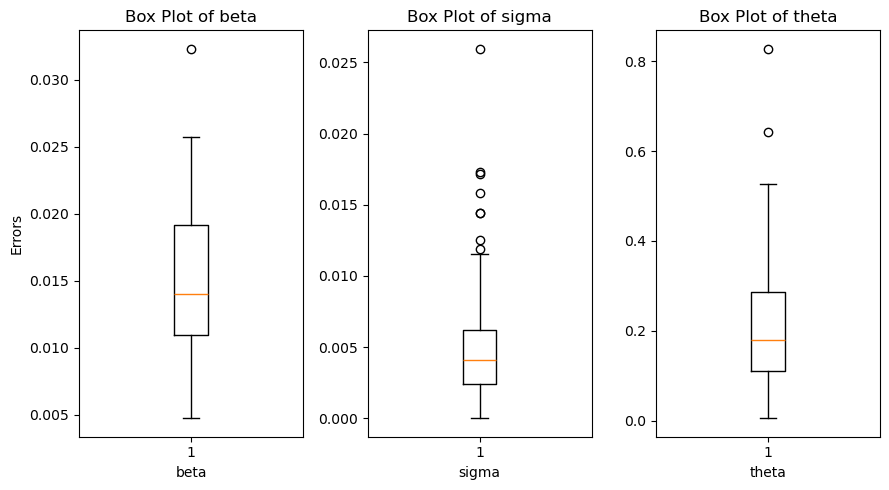

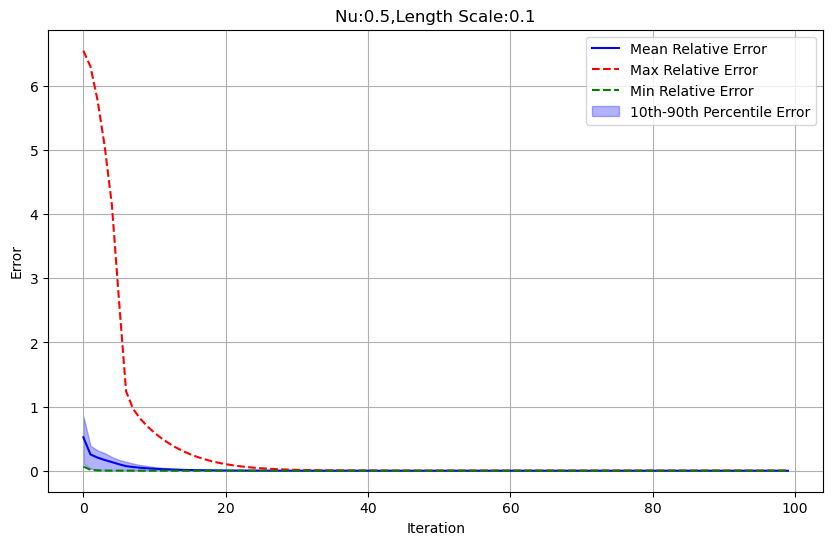

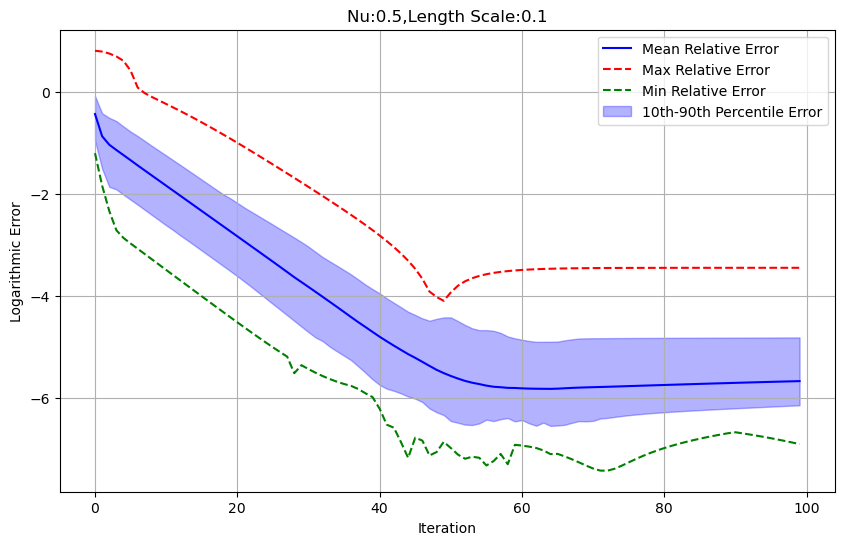

/tmp/ipykernel_3392840/4035658662.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([alphas_mle] + [alphas_de[:, j] for j in range(10)], labels=['MLE'] + [f'DE_{j+1}' for j in range(10)])
/tmp/ipykernel_3392840/4035658662.py:153: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([length_scales_mle] + [length_scales_de[:, j] for j in range(10)], labels=['MLE'] + [f'DE_{j+1}' for j in range(10)])


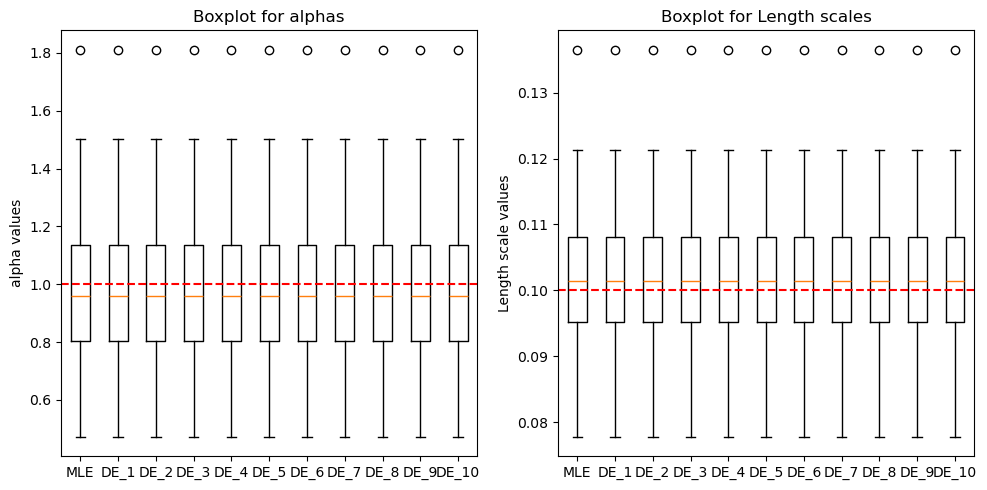

In [ ]:
theta=torch.tensor([1,0.1],dtype=torch.float64)
length_scale=0.1
nu=0.5
beta=torch.tensor([-1,2,3,-2,1],dtype=torch.float64)
delta=torch.tensor(0.25,dtype=torch.float64)
alpha=1
J=10
scale=torch.tensor([1,math.sqrt(3)])
Ns=[10000,20000,40000]
#Ns=[10000]
for N in Ns:
    with open(f'expriements/decentralized/varying_sample_size/more_irregular/N_{N}_memeff.pkl', 'rb') as f:
        results=pickle.load(f)
    param_rel_error=np.zeros(shape=(100,100))
    sta_error_beta=np.zeros(shape=(100,))
    sta_error_delta=np.zeros(shape=(100,))
    sta_error_theta=np.zeros(shape=(100,))
    for r in range(100):

        sta_error_beta[r]=torch.norm((results[r][1][2].squeeze()-beta)/torch.abs(beta))
        sta_error_delta[r]=torch.norm((results[r][1][3].squeeze()-delta)/torch.abs(delta))
        sta_error_theta[r]=torch.norm((results[r][1][4].squeeze()-theta)/torch.abs(theta))
        for t in range(100):
            rel_error=torch.zeros((J,))
            for j in range(J):
                rel_dif_beta=torch.abs(results[r][0][2][t][j]-results[r][1][2]).squeeze()/torch.abs(beta)
                rel_dif_delta=torch.abs(results[r][0][3][t][j]-results[r][1][3]).squeeze()/torch.abs(delta)
                rel_dif_theta=torch.abs(results[r][0][4][t][j]-results[r][1][4]).squeeze()/torch.abs(theta)
                rel_error[j]=torch.sqrt(torch.square(torch.norm(rel_dif_beta))+torch.square(torch.norm(rel_dif_delta))+torch.square(torch.norm(rel_dif_theta)))
            param_rel_error[r,t]=rel_error.max().numpy()
    
   
    # Calculate the mean, standard deviation, max, and min across replications for each iteration
    
    mean_rel_error= np.mean(param_rel_error, axis=0)
    std_rel_error = np.std(param_rel_error, axis=0)
    percentile_10_error = np.percentile(param_rel_error, 10, axis=0)
    percentile_90_error = np.percentile(param_rel_error, 90, axis=0)
    max_rel_error = np.max(param_rel_error, axis=0)
    min_rel_error = np.min(param_rel_error, axis=0)
    


    #box plot
    fig, axs = plt.subplots(1, 3, figsize=(9, 5))
    axs[0].boxplot(sta_error_beta)
    axs[0].set_title('Box Plot of beta')
    axs[0].set_xlabel('beta')
    axs[0].set_ylabel('Errors')

    # Plot the second box plot for sta_error_delta
    axs[1].boxplot(sta_error_delta)
    axs[1].set_title('Box Plot of sigma')
    axs[1].set_xlabel('sigma')

    # Plot the third box plot for sta_error_theta
    axs[2].boxplot(sta_error_theta)
    axs[2].set_title('Box Plot of theta')
    axs[2].set_xlabel('theta')

    #Adjust layout and display the plots
    plt.tight_layout()
    plt.savefig(f'expriements/decentralized/varying_sample_size/more_irregular/stat_error_N_{N}.pdf', dpi=300)
    plt.show()

    # Plot the mean convergence curve
    plt.figure(figsize=(10, 6))
    plt.plot(mean_rel_error, label='Mean Relative Error', color='blue')

    # Plot the max and min convergence curves
    plt.plot(max_rel_error, label='Max Relative Error', color='red', linestyle='--')
    plt.plot(min_rel_error, label='Min Relative Error', color='green', linestyle='--')

    # Fill between the 25th and 75th percentiles
    plt.fill_between(range(100), percentile_10_error, percentile_90_error, color='blue', alpha=0.3, label='10th-90th Percentile Error')

    # Customize the plot
    plt.title(f'Nu:{nu},Length Scale:{length_scale}')
    plt.xlabel('Iteration')
    plt.ylabel('Error')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'expriements/decentralized/varying_sample_size/more_irregular/opt_error_N_{N}.pdf', dpi=300)  
    # Show the plot
    plt.show()


    param_rel_error=np.log10(param_rel_error)
    mean_rel_error= np.mean(param_rel_error, axis=0)
    std_rel_error = np.std(param_rel_error, axis=0)
    percentile_10_error = np.percentile(param_rel_error, 10, axis=0)
    percentile_90_error = np.percentile(param_rel_error, 90, axis=0)
    max_rel_error = np.max(param_rel_error, axis=0)
    min_rel_error = np.min(param_rel_error, axis=0)
    plt.figure(figsize=(10, 6))
    plt.plot(mean_rel_error, label='Mean Relative Error', color='blue')

    # Plot the max and min convergence curves
    plt.plot(max_rel_error, label='Max Relative Error', color='red', linestyle='--')
    plt.plot(min_rel_error, label='Min Relative Error', color='green', linestyle='--')

    # Fill between the 25th and 75th percentiles
    plt.fill_between(range(100), percentile_10_error, percentile_90_error, color='blue', alpha=0.3, label='10th-90th Percentile Error')

    # Customize the plot
    plt.title(f'Nu:{nu},Length Scale:{length_scale}')
    plt.xlabel('Iteration')
    plt.ylabel('Logarithmic Error')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'expriements/decentralized/varying_sample_size/more_irregular/opt_logerror_N_{N}.pdf', dpi=300)  
    # Show the plot
    plt.show()

    plt.figure(figsize=(10, 5))

    #box plot for covariance parameter theta
    alphas_de=np.zeros((100,10))
    length_scales_de=np.zeros((100,10))
    alphas_mle=np.zeros((100,))
    length_scales_mle=np.zeros((100,))
    
    for r in range(100):
        
        alphas_mle[r]=results[r][1][4][0]
        length_scales_mle[r]=results[r][1][4][1]
        for j in range(10): 
            alphas_de[r,j]=results[r][0][4][99][j][0]
            length_scales_de[r,j]=results[r][0][4][99][j][1]
    
    # Box plot for alphas
    plt.subplot(1, 2, 1)
    plt.boxplot([alphas_mle] + [alphas_de[:, j] for j in range(10)], labels=['MLE'] + [f'DE_{j+1}' for j in range(10)])
    plt.axhline(y=alpha, color='r', linestyle='--', label='True Alpha')
    plt.title('Boxplot for alphas')
    plt.ylabel('alpha values')

    # Box plot for length scales
    plt.subplot(1, 2, 2)
    plt.boxplot([length_scales_mle] + [length_scales_de[:, j] for j in range(10)], labels=['MLE'] + [f'DE_{j+1}' for j in range(10)])
    plt.axhline(y=length_scale, color='r', linestyle='--', label='True Length Scale')
    plt.title('Boxplot for Length scales')
    plt.ylabel('Length scale values')

    plt.tight_layout()
    plt.savefig(f'expriements/decentralized/varying_sample_size/more_irregular/boxplot_covpara_N_{N}.pdf', dpi=300)
    plt.show()


In [7]:
#Comparison

#Ns*{de,MLE}*reps*dims
result_beta=torch.zeros((3,2,100,5),dtype=torch.double)
result_delta=torch.zeros((3,2,100),dtype=torch.double)
result_theta=torch.zeros((3,2,100,2),dtype=torch.double)
Ns=[10000,20000,40000]
for i in range(3):
    N=Ns[i]
    with open(f'expriements/decentralized/varying_sample_size/more_irregular/N_{N}_memeff.pkl', 'rb') as f:
        results=pickle.load(f)
        for r in range(100):
            
            result_beta[i,1,r,:]=results[r][1][2].squeeze()
            result_delta[i,1,r]=results[r][1][3].squeeze()
            result_theta[i,1,r,:]=results[r][1][4].squeeze()
            #take the average of local machines
            temp_beta=torch.zeros_like(results[r][0][2][99][0].squeeze(),dtype=torch.double)
            temp_delta=torch.zeros_like(results[r][0][3][99][0].squeeze(),dtype=torch.double)
            temp_theta=torch.zeros_like(results[r][0][4][99][0].squeeze(),dtype=torch.double)
            for j in range(10):
                temp_beta=temp_beta+results[r][0][2][99][j].squeeze()
                temp_delta=temp_delta+results[r][0][3][99][j].squeeze()
                temp_theta=temp_theta+results[r][0][4][99][j].squeeze()
            temp_beta=temp_beta/10
            temp_delta=temp_delta/10
            temp_theta=temp_theta/10
            
            result_beta[i,0,r,:]=temp_beta
            result_delta[i,0,r]=temp_delta
            result_theta[i,0,r,:]=temp_theta


In [8]:

def box_plot_Ns(result,true_value,ylabel=None,filepath=None,Ns=[10000,20000,40000],methods=['DE','MLE']):
        
    # Preparing data for boxplot: collapse the reps and dims for each sample size and method
    data_for_boxplot = []
    labels = []
   
    for s in range(result.shape[0]):
        for m in reversed(range(result.shape[1])): 
            N=Ns[s]
            method=methods[m]        
            data_for_boxplot.append(result[s,m])
            method_label = f"{int(N/1000)}K - {method}"
            labels.append(method_label)

    # Setting the positions for boxplots, keeping two methods closer and adding space between sample sizes
    positions = []
    for i in range(result.shape[0]):
        positions.append(i * 2)      # Position for Method 1
        positions.append(i * 2 + 0.8)  # Slightly offset position for Method 2

    # Plotting the boxplot
    fig, ax = plt.subplots(figsize=(7, 5))
    plt.subplots_adjust(top=0.9)
    colors = ['skyblue', 'salmon']  # Define colors for the methods
    boxplots = ax.boxplot(data_for_boxplot, positions=positions, widths=0.6, patch_artist=True,medianprops={'color': 'blue'})  # Patch artist for color fill

    # Apply color to each box
    for patch, method_idx in zip(boxplots['boxes'], [m % 2 for m in range(len(data_for_boxplot))]):
        patch.set_facecolor(colors[method_idx])
    
    # Adjusting x-axis ticks
    # ax.set_xticks(positions)  # Center ticks between Method 1 and Method 2
    # ax.set_xticklabels(labels, rotation=0)
    
    
    ax.set_xticks([np.mean([positions[i], positions[i+1]]) for i in range(0, len(positions), 2)])
    ax.set_xticklabels([f"{int(N/1000)}K" for N in Ns], rotation=0, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    
    handles = [plt.Line2D([0], [0], color=color, lw=4) for color in colors]
    handles.append(plt.Line2D([0], [0], color='r', linestyle='--', lw=2))
    ax.legend(handles, list(reversed(methods))+['True Value'], loc='upper right', fontsize=14)
    
    # # Axis labels and title
    # ax.set_xlabel("Sample Size")
    # ax.set_ylabel("Beta Estimate")
    ax.set_xlabel("Sample Size",fontsize=14)
    if ylabel:
        ax.set_ylabel(ylabel,fontsize=16)
    # plt.grid(True)
    plt.axhline(y=true_value, color='r', linestyle='--', label='The truth')
    
    if filepath:
        plt.savefig(filepath)
    plt.show()

In [16]:
import numpy as np

def box_plot_Ns(result, true_value, title=None, filepath=None, Ns=[10000, 20000, 40000], methods=['DE', 'MLE']):
    # Preparing data for boxplot: collapse the reps and dims for each sample size and method
    data_for_boxplot = []
    labels = []
   
    for s in range(result.shape[0]):
        for m in reversed(range(result.shape[1])): 
            N = Ns[s]
            method = methods[m]        
            data_for_boxplot.append(result[s, m])
            method_label = f"{int(N/1000)}K - {method}"
            labels.append(method_label)

    # Setting the positions for boxplots, keeping two methods closer and adding space between sample sizes
    positions = []
    for i in range(result.shape[0]):
        positions.append(i * 3)        # Position for Method 1
        positions.append(i * 3 + 0.8)  # Slightly offset position for Method 2

    # Plotting the boxplot
    fig, ax = plt.subplots(figsize=(12, 7))
    colors = ['skyblue', 'salmon']  # Define colors for the methods
    boxplots = ax.boxplot(data_for_boxplot, positions=positions, widths=0.6, patch_artist=True,medianprops={'color': 'blue'})  # Patch artist for color fill

    # Apply color to each box
    for patch, method_idx in zip(boxplots['boxes'], [m % 2 for m in range(len(data_for_boxplot))]):
        patch.set_facecolor(colors[method_idx])
    
    # # Adding mean lines for each method
    # for pos, data in zip(positions, data_for_boxplot):
    #     mean_val = torch.mean(data)
    #     ax.plot(pos, mean_val, 'ro', markersize=6)  # Red dot for the mean

    # Adjusting x-axis ticks
    ax.set_xticks([np.mean([positions[i], positions[i+1]]) for i in range(0, len(positions), 2)])
    ax.set_xticklabels([f"{int(N/1000)}K" for N in Ns], rotation=0, fontsize=12)

    # Axis labels and title
    ax.set_xlabel("Sample Size", fontsize=14)
    #ax.set_ylabel("Beta Estimate", fontsize=14)
    if title:
        ax.set_title(title, fontsize=16)

    # Adding grid and the true value line
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(y=true_value, color='r', linestyle='--', label='True Value')
    
    # Adding legend for color-coded methods
    handles = [plt.Line2D([0], [0], color=color, lw=4) for color in colors]
    handles.append(plt.Line2D([0], [0], color='r', linestyle='--', lw=2))
    ax.legend(handles, methods + ['True Value'], loc='upper right', fontsize=12)

    # Saving or showing the plot
    if filepath:
        plt.savefig(filepath)
    plt.show()

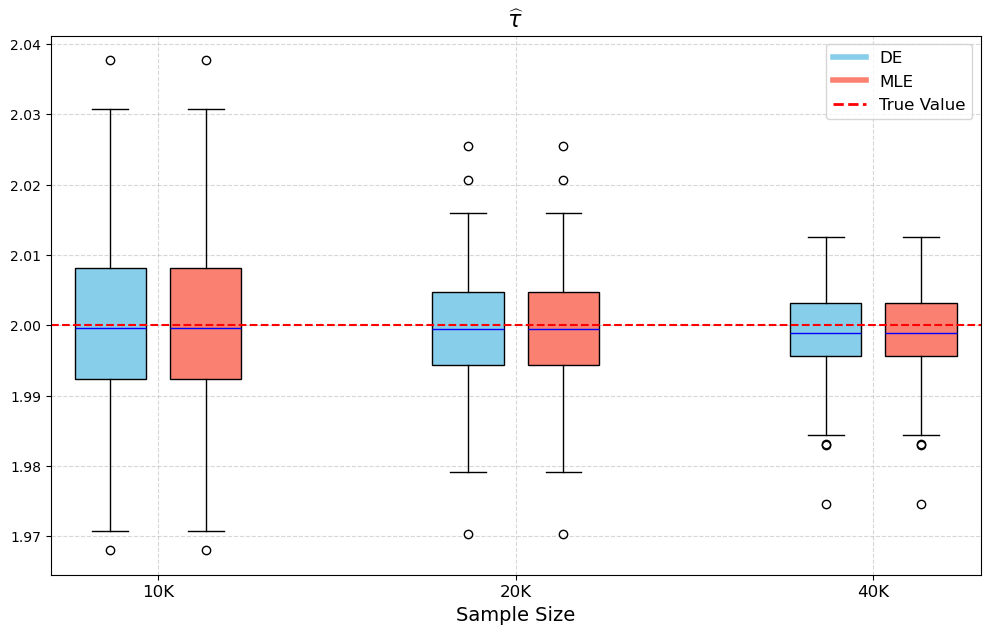

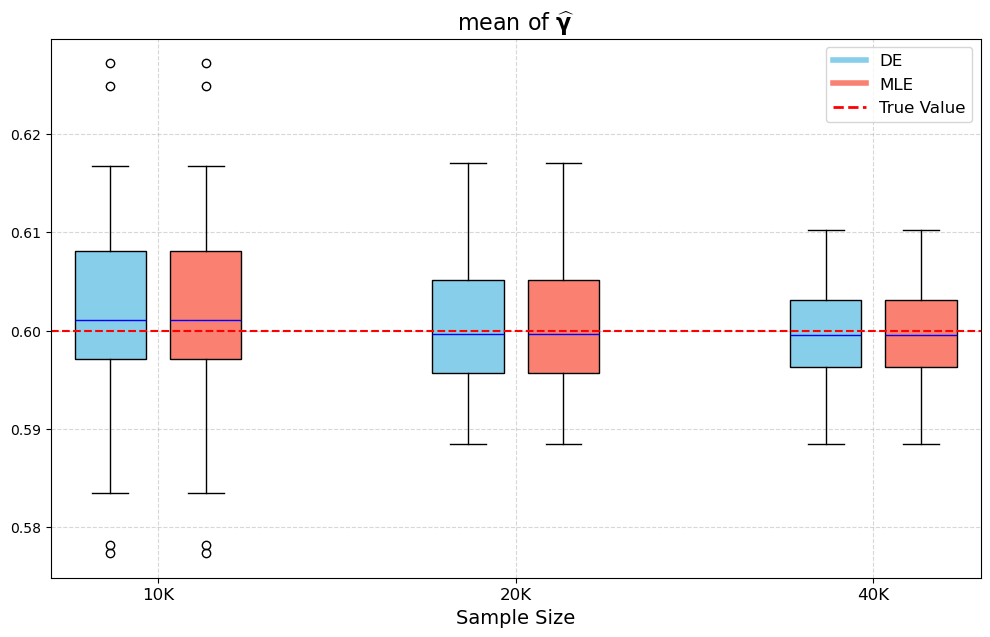

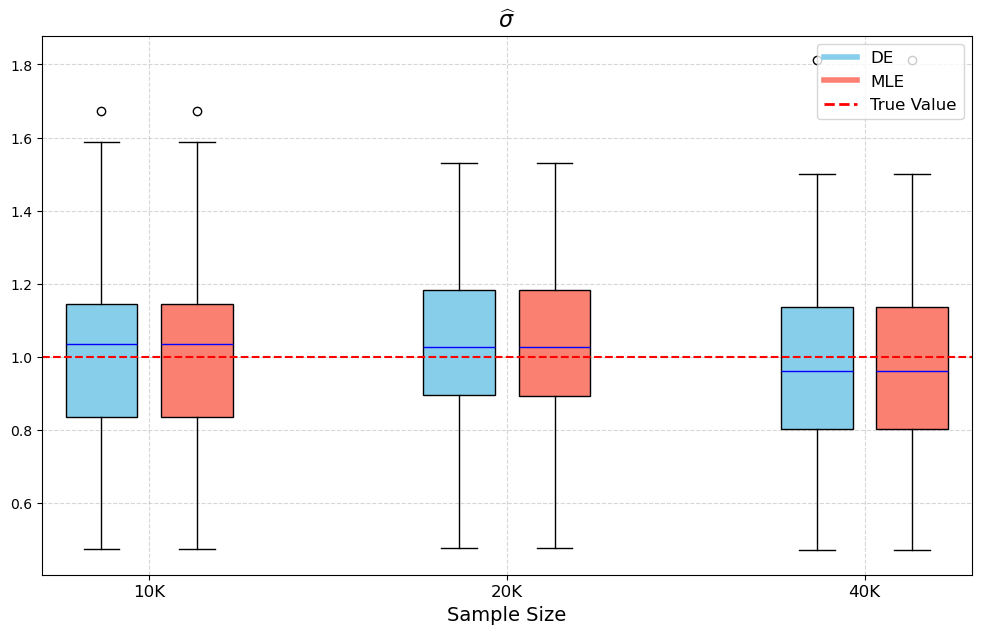

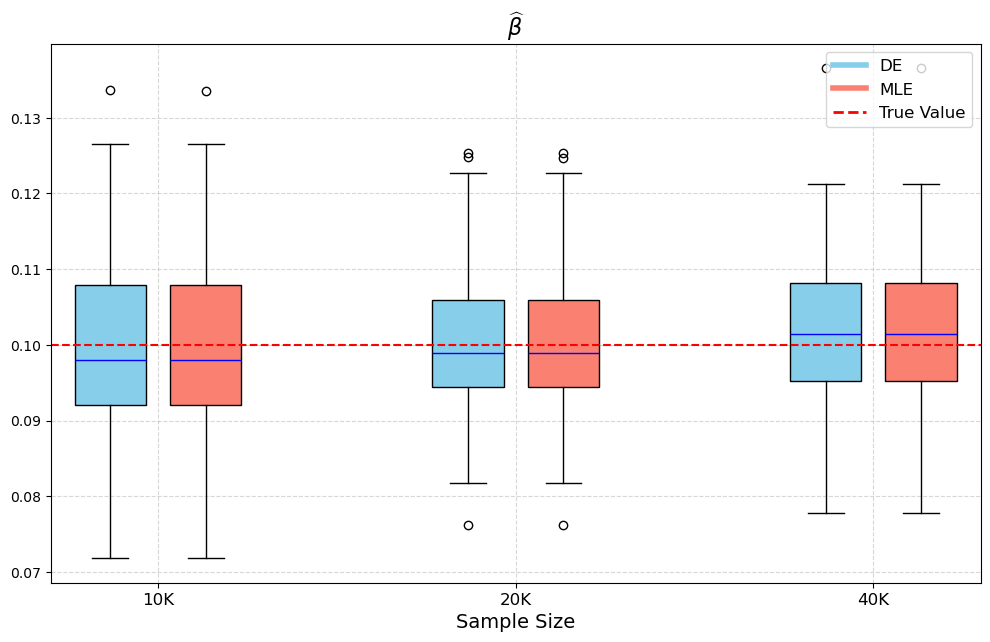

In [17]:

theta=torch.tensor([1,0.1],dtype=torch.float64)
length_scale=0.1
nu=0.5
beta=torch.tensor([-1,2,3,-2,1],dtype=torch.float64)
delta=torch.tensor(0.25,dtype=torch.float64)
alpha=1
J=10
scale=torch.tensor([1,math.sqrt(3)])
box_plot_Ns(1/torch.sqrt(result_delta),1/torch.sqrt((delta)),r'$\widehat{\tau}$',f'expriements/decentralized/varying_sample_size/more_irregular/box_com_delta.pdf')
box_plot_Ns(torch.mean(result_beta,dim=3),torch.mean(beta),r'mean of $\widehat{\mathbf{\gamma}}$',f'expriements/decentralized/varying_sample_size/more_irregular/box_com_mean_beta.pdf')
box_plot_Ns(result_theta[:,:,:,0],theta[0],r'$\widehat{\sigma}$',f'expriements/decentralized/varying_sample_size/more_irregular/box_com_alpha.pdf')
box_plot_Ns(result_theta[:,:,:,1],theta[1],r'$\widehat{\beta}$',f'expriements/decentralized/varying_sample_size/more_irregular/box_com_length_scale.pdf')

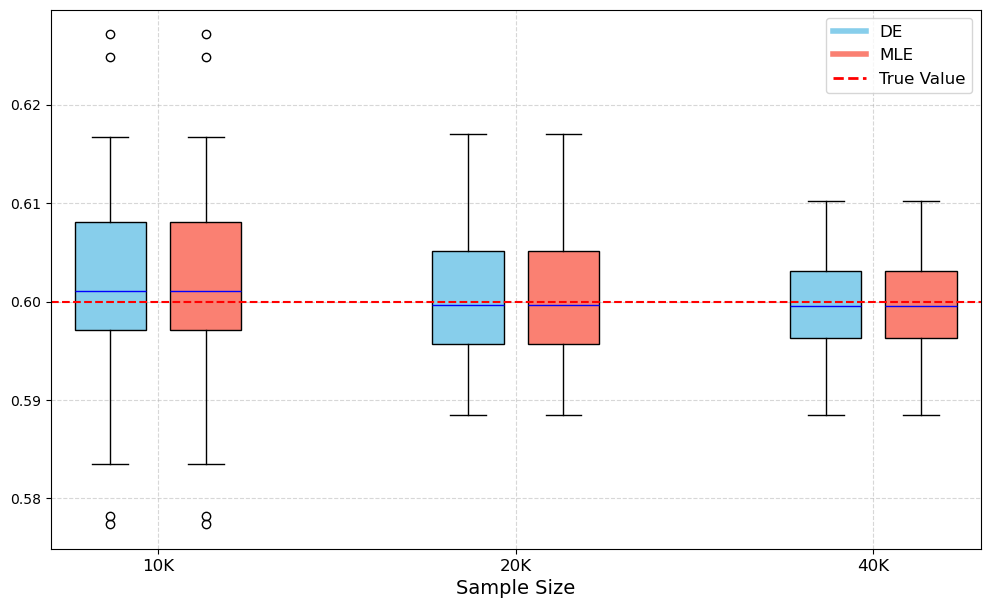

In [18]:
box_plot_Ns(torch.mean(result_beta,dim=3),torch.mean(beta))

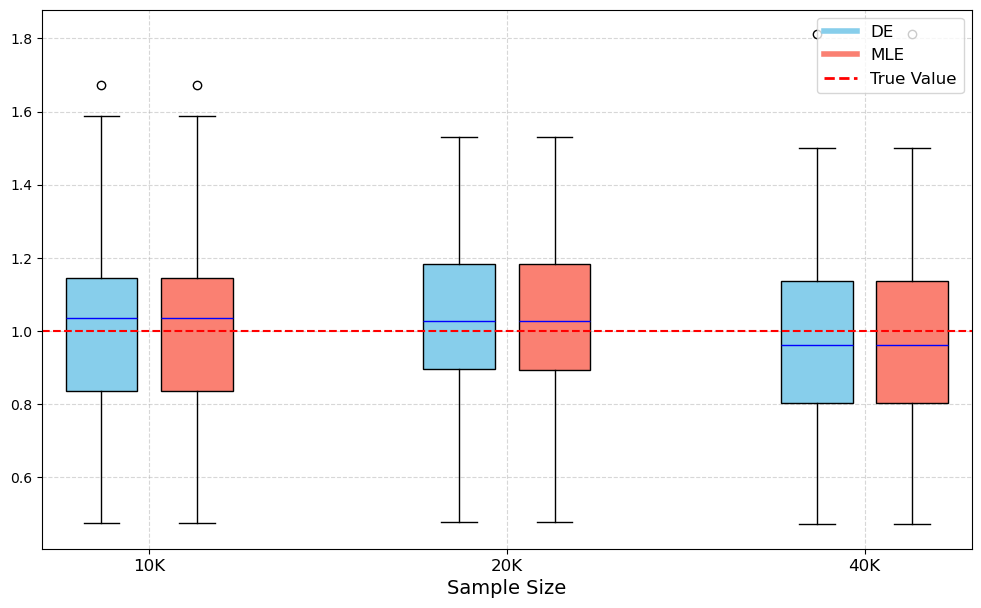

In [19]:
box_plot_Ns(result_theta[:,:,:,0],theta[0])

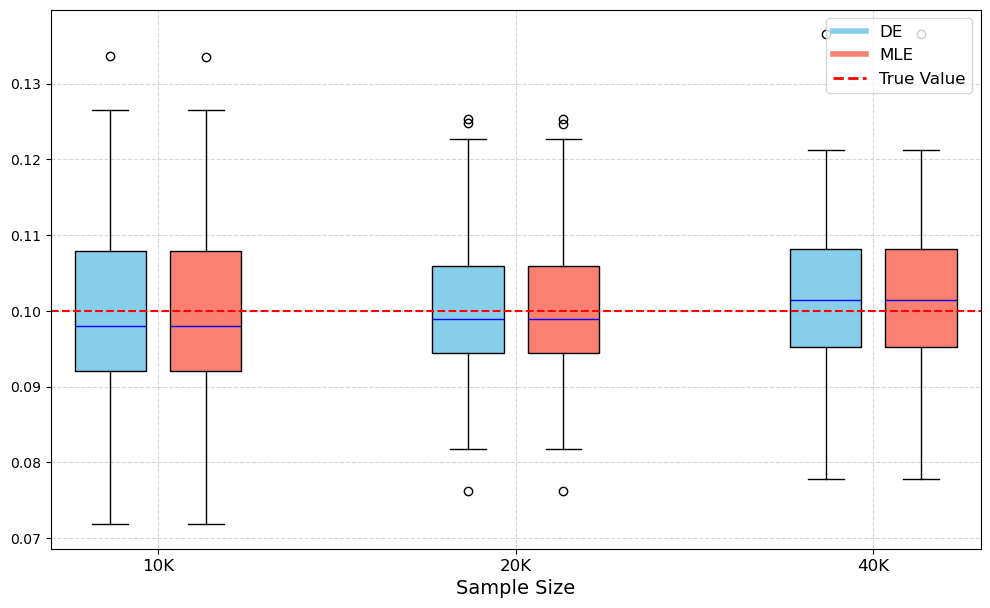

In [20]:
box_plot_Ns(result_theta[:,:,:,1],theta[1])